In [2]:
#Quering data with sql
#New tools learned JupyterLab, SQLite, SQL (SELECT, WHERE, ORDER BY, GROUP BY, aggregate functions), pd.read_sql
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [4]:
#Task 1 set up
conn = sqlite3.connect('finance.db') #Opens or creates the database file
try: 
    df = pd.read_csv ('.ipynb_checkpoints/historical_prices.csv')
    df.to_sql('prices', conn, if_exists ='replace' , index=False)
except FileNotFoundError:
    print("Could not find historical_prices.csv - check the filename & folder path")

In [5]:
#Task 2
query = "SELECT * FROM prices"
result = pd.read_sql(query, conn)
print(result.head())

         date ticker   close
0  2024-06-01   AAPL  165.00
1  2024-07-01   AAPL  179.13
2  2024-08-01   AAPL  179.01
3  2024-09-01   AAPL  182.47
4  2024-10-01   AAPL  188.73


In [6]:
#Task 3 Selecting & filtering
query = "SELECT date close FROM prices WHERE ticker = 'AAPL'"
aapl = pd.read_sql(query,conn)
print(aapl)

         close
0   2024-06-01
1   2024-07-01
2   2024-08-01
3   2024-09-01
4   2024-10-01
5   2024-11-01
6   2024-12-01
7   2025-01-01
8   2025-02-01
9   2025-03-01
10  2025-04-01
11  2025-05-01


In [7]:
#Task 4 Sorting
query = "SELECT date, ticker, close FROM prices ORDER BY close DESC"
print(pd.read_sql(query, conn))

          date ticker   close
0   2025-01-01   NVDA  579.77
1   2024-11-01   NVDA  545.60
2   2024-12-01   NVDA  534.58
3   2025-02-01   NVDA  521.56
4   2024-09-01   NVDA  506.81
5   2024-10-01   NVDA  485.97
6   2024-08-01   NVDA  404.71
7   2024-06-01   NVDA  400.00
8   2025-03-01   NVDA  399.43
9   2024-07-01   NVDA  334.56
10  2025-04-01   MSFT  318.79
11  2025-05-01   NVDA  318.22
12  2025-02-01   MSFT  317.68
13  2025-03-01   MSFT  306.31
14  2024-07-01   MSFT  306.12
15  2024-07-01   EQNR  305.18
16  2025-05-01   MSFT  302.77
17  2024-12-01   MSFT  301.03
18  2025-04-01   NVDA  300.60
19  2024-06-01   EQNR  300.00
20  2024-06-01   MSFT  300.00
21  2025-01-01   MSFT  299.83
22  2024-09-01   MSFT  299.64
23  2024-11-01   MSFT  298.81
24  2024-08-01   EQNR  298.75
25  2024-08-01   MSFT  297.32
26  2024-09-01   EQNR  292.73
27  2024-10-01   MSFT  282.23
28  2025-01-01   EQNR  275.50
29  2024-11-01   EQNR  274.43
30  2024-12-01   EQNR  273.94
31  2025-03-01   EQNR  271.07
32  2025-0

In [8]:
#Task 5 Aggregate functions
queru = "SELECT COUNT(*),AVG(close), MAX(close), MIN(close) FROM prices"
print(pd.read_sql(query,conn))

          date ticker   close
0   2025-01-01   NVDA  579.77
1   2024-11-01   NVDA  545.60
2   2024-12-01   NVDA  534.58
3   2025-02-01   NVDA  521.56
4   2024-09-01   NVDA  506.81
5   2024-10-01   NVDA  485.97
6   2024-08-01   NVDA  404.71
7   2024-06-01   NVDA  400.00
8   2025-03-01   NVDA  399.43
9   2024-07-01   NVDA  334.56
10  2025-04-01   MSFT  318.79
11  2025-05-01   NVDA  318.22
12  2025-02-01   MSFT  317.68
13  2025-03-01   MSFT  306.31
14  2024-07-01   MSFT  306.12
15  2024-07-01   EQNR  305.18
16  2025-05-01   MSFT  302.77
17  2024-12-01   MSFT  301.03
18  2025-04-01   NVDA  300.60
19  2024-06-01   EQNR  300.00
20  2024-06-01   MSFT  300.00
21  2025-01-01   MSFT  299.83
22  2024-09-01   MSFT  299.64
23  2024-11-01   MSFT  298.81
24  2024-08-01   EQNR  298.75
25  2024-08-01   MSFT  297.32
26  2024-09-01   EQNR  292.73
27  2024-10-01   MSFT  282.23
28  2025-01-01   EQNR  275.50
29  2024-11-01   EQNR  274.43
30  2024-12-01   EQNR  273.94
31  2025-03-01   EQNR  271.07
32  2025-0

In [9]:
#Task 6 GROUP BY (new concept)
query = '''
    SELECT ticker, 
            COUNT(*) AS months,
            AVG(close) AS avg_price,
            MAX(close) AS high,
            MIN(close) AS low
    FROM prices
    GROUP BY ticker
'''
summary = pd.read_sql(query, conn)
print(summary)

  ticker  months   avg_price    high     low
0   AAPL      12  186.795000  201.74  165.00
1   EQNR      12  278.964167  305.18  252.27
2   MSFT      12  302.544167  318.79  282.23
3   NVDA      12  444.317500  579.77  300.60


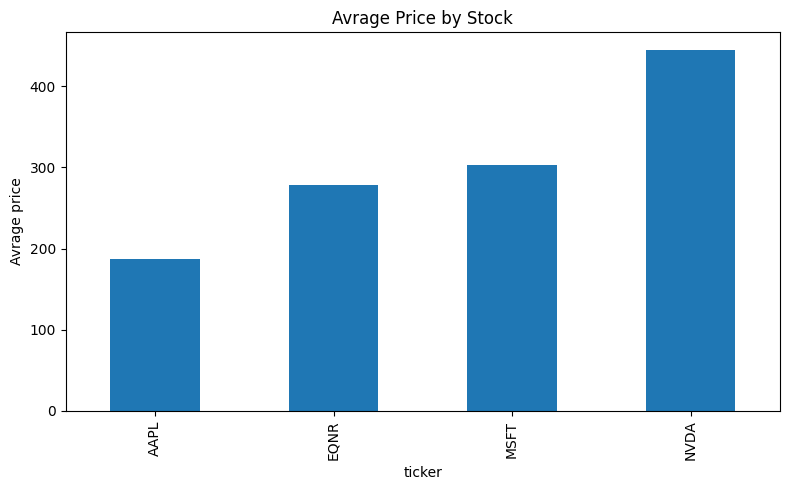

In [10]:
#Task 7 Combiene SQL with your earlier skills
summary.plot(x='ticker', y='avg_price', kind='bar',
             figsize=(8,5), title='Avrage Price by Stock', legend=False)
plt.ylabel('Avrage price')
plt.tight_layout()
plt.show()        

In [18]:
#Task 8 Close the connenction
#conn.close() #Closing the connection is a proffesional code habit. Its like closing a file after reading it

In [11]:
#Strech goal joining two tables
port = pd.read_csv('portfolio.csv')
conn = sqlite3.connect('finance.db')
port.to_sql('portfolio', conn, if_exists='replace', index=False)

query = '''
        SELECT p.date, p.ticker, f.name, p.close, f.shares
        FROM prices AS p
        JOIN portfolio AS f ON p.ticker = f.ticker
        ORDER BY p.date
'''
joined = pd.read_sql (query, conn)
print(joined.head())
conn.close() #Added twice since it is apart of the tasks


         date ticker             name   close  shares
0  2024-06-01   AAPL       Apple Inc.  165.00      10
1  2024-06-01   EQNR      Equinor ASA  300.00      25
2  2024-06-01   MSFT  Microsoft Corp.  300.00       5
3  2024-06-01   NVDA     NVIDIA Corp.  400.00       8
4  2024-07-01   AAPL       Apple Inc.  179.13      10
